In [1]:
import pandas as pd
import os
import seaborn as sns
import re
import json
import numpy as np

In [2]:
import os
import re
import json
import pandas as pd
import numpy as np

# --- Configuration ---
FILE_PATH = "../data/Scenario_6"
TIME_WINDOW = '50ms'
OUTPUT_FILENAME = f'../data/scenario_6_marina_features_{TIME_WINDOW}_final.csv'

# --- Parsing Functions (No changes needed) ---
def parse_statistics(file_path):
    stats_records = []
    try:
        with open(file_path, 'r', errors='ignore') as f:
            for line in f:
                try:
                    parts = line.split('::', 1)
                    if len(parts) < 2: continue
                    timestamp = float(parts[0])
                    data_prefix = 'data="'
                    json_start_index = parts[1].find(data_prefix)
                    if json_start_index == -1: continue
                    json_string = parts[1][json_start_index + len(data_prefix):]
                    if json_string.endswith('}"\n'): json_string = json_string[:-3]
                    elif json_string.endswith('}"'): json_string = json_string[:-2]
                    else: continue
                    json_data = json.loads(json_string + '}')
                    record = {'timestamp': timestamp, 'bwe': int(json_data.get('bwe', np.nan)), 'buffer_level_ms': int(json_data.get('bh', np.nan))}
                    stats_records.append(record)
                except (json.JSONDecodeError, IndexError, ValueError, KeyError): continue
        if not stats_records: return None
        df = pd.DataFrame(stats_records)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        return df.set_index('timestamp')
    except FileNotFoundError: return None

def parse_tcpdump(file_path):
    tcp_pattern = re.compile(r'(?P<timestamp>\d+\.\d+).*? length (?P<length>\d+)')
    packet_records = []
    try:
        with open(file_path, 'r', errors='ignore') as f:
            content = f.read()
            for match in tcp_pattern.finditer(content):
                packet_records.append({'timestamp': float(match.group('timestamp')), 'length': int(match.group('length'))})
        if not packet_records: return None
        df = pd.DataFrame(packet_records)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        return df
    except FileNotFoundError: return None

# --- Main Processing Logic ---
all_processed_dfs = []
print(f"Starting processing in: {os.path.abspath(FILE_PATH)}")
print(f"Using time window: {TIME_WINDOW}")
os.makedirs(os.path.dirname(OUTPUT_FILENAME), exist_ok=True)

for video_id in os.listdir(FILE_PATH):
    video_path = os.path.join(FILE_PATH, video_id)
    if not os.path.isdir(video_path): continue
    for iteration in os.listdir(video_path):
        iteration_path = os.path.join(video_path, iteration)
        if not os.path.isdir(iteration_path): continue
        print(f"  Processing {video_id}/{iteration}...")
        
        stats_file = next((os.path.join(iteration_path, f) for f in os.listdir(iteration_path) if "Phone_Statistics" in f), None)
        tcpdump_file = next((os.path.join(iteration_path, f) for f in os.listdir(iteration_path) if "Phone_TCPdump" in f), None)

        if not stats_file or not tcpdump_file: continue
            
        stats_df = parse_statistics(stats_file)
        packets_df = parse_tcpdump(tcpdump_file)

        if stats_df is None or packets_df is None or stats_df.empty or packets_df.empty:
            print(f"    Warning: Failed to parse data or file is empty. Skipping.")
            continue
            
        stats_df.index = stats_df.index + pd.Timedelta(hours=1)
        
        # ***** THE FINAL FIX: Filter outlier packets based on the stats time range *****
        start_time = stats_df.index.min() - pd.Timedelta(seconds=10)
        end_time = stats_df.index.max() + pd.Timedelta(seconds=10)
        
        original_packet_count = len(packets_df)
        packets_df = packets_df[(packets_df['timestamp'] >= start_time) & (packets_df['timestamp'] <= end_time)]
        
        if packets_df.empty:
            print(f"    Warning: No packets found within the valid time range. Skipping.")
            continue
        # ******************************************************************************

        print(f"    Parsed {original_packet_count} packets, kept {len(packets_df)} within the valid time range.")
        print(f"    Packet time range (CLEANED): {packets_df['timestamp'].min()} to {packets_df['timestamp'].max()}")
        print(f"    Stats time range (ADJUSTED):  {stats_df.index.min()} to {stats_df.index.max()}")

        packets_df.set_index('timestamp', inplace=True)
        packets_df['iat_ms'] = packets_df.index.to_series().diff().dt.total_seconds().fillna(0) * 1000
        packets_df.rename(columns={'length': 'ps'}, inplace=True)
        packets_df['ps2'] = packets_df['ps'] ** 2
        packets_df['ps3'] = packets_df['ps'] ** 3
        packets_df['iat2'] = packets_df['iat_ms'] ** 2
        packets_df['iat3'] = packets_df['iat_ms'] ** 3
        
        agg_rules = {'ps': ['sum', 'count'], 'ps2': 'sum', 'ps3': 'sum', 'iat_ms': 'sum', 'iat2': 'sum', 'iat3': 'sum'}
        features_df = packets_df.resample(TIME_WINDOW).agg(agg_rules)
        features_df.columns = ['ps_sum', 'packet_count', 'ps2_sum', 'ps3_sum', 'iat_sum', 'iat2_sum', 'iat3_sum']
        
        merged_df = pd.merge_asof(left=features_df.sort_index(), right=stats_df.sort_index(), left_index=True, right_index=True, direction='nearest', tolerance=pd.Timedelta('100ms'))
        
        print(f"    Rows after merge: {len(merged_df)}")
        valid_merges = merged_df['buffer_level_ms'].notna().sum()
        print(f"    Rows with successful merges (non-NaN stats): {valid_merges}")

        if valid_merges == 0: continue

        merged_df['video_id'] = video_id
        merged_df['iteration'] = iteration
        all_processed_dfs.append(merged_df)


Starting processing in: c:\Users\Administrator\Desktop\thesis\data\Scenario_6
Using time window: 50ms
  Processing Vid_2d1VrCvdzbY/Iteration_1...
    Parsed 274768 packets, kept 137427 within the valid time range.
    Packet time range (CLEANED): 2018-02-01 02:19:51.472589016 to 2018-02-01 02:29:13.044424057
    Stats time range (ADJUSTED):  2018-02-01 02:19:54 to 2018-02-01 02:29:13
    Rows after merge: 11232
    Rows with successful merges (non-NaN stats): 2793
  Processing Vid_2d1VrCvdzbY/Iteration_10...
    Parsed 275582 packets, kept 137872 within the valid time range.
    Packet time range (CLEANED): 2018-01-25 19:51:46.686403990 to 2018-01-25 20:01:09.857115030
    Stats time range (ADJUSTED):  2018-01-25 19:51:50 to 2018-01-25 20:01:09
    Rows after merge: 11265
    Rows with successful merges (non-NaN stats): 2630
  Processing Vid_2d1VrCvdzbY/Iteration_11...
    Parsed 274342 packets, kept 137252 within the valid time range.
    Packet time range (CLEANED): 2018-01-23 14:59:

In [3]:
if not all_processed_dfs:
    print("\nNo data was processed successfully. The final CSV will be empty.")
else:
    final_df = pd.concat(all_processed_dfs)
    final_df.dropna(subset=['buffer_level_ms', 'bwe'], inplace=True)
    print(f"\nTotal rows after concatenating and dropping NaNs: {len(final_df)}")

    if not final_df.empty:
        final_df.reset_index(inplace=True)
        final_df['timestamp'] = (final_df['timestamp'].astype(np.int64) // 10**6)
        feature_cols = ['packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum', 'iat_sum', 'iat2_sum', 'iat3_sum']
        label_cols = ['buffer_level_ms', 'bwe']
        id_cols = ['timestamp', 'video_id', 'iteration']
        for col in label_cols:
            final_df[col] = final_df[col].astype(int)
        final_df = final_df[id_cols + feature_cols + label_cols]
        final_df.to_csv(OUTPUT_FILENAME, index=False)
        print(f"\nProcessing complete. Data saved to '{OUTPUT_FILENAME}'")
        print(f"Total rows created: {len(final_df)}")
        print("\nFinal DataFrame Head:")
        print(final_df.head())
    else:
        print("Final DataFrame is empty after cleanup. No file will be saved.")


Total rows after concatenating and dropping NaNs: 163090

Processing complete. Data saved to '../data/scenario_6_marina_features_50ms_final.csv'
Total rows created: 163090

Final DataFrame Head:
       timestamp         video_id    iteration  packet_count  ps_sum  \
0  1517451593900  Vid_2d1VrCvdzbY  Iteration_1            82   76301   
1  1517451593950  Vid_2d1VrCvdzbY  Iteration_1            73   67845   
2  1517451594000  Vid_2d1VrCvdzbY  Iteration_1            69   66253   
3  1517451594050  Vid_2d1VrCvdzbY  Iteration_1            71   66387   
4  1517451594100  Vid_2d1VrCvdzbY  Iteration_1            71   66387   

     ps2_sum       ps3_sum    iat_sum   iat2_sum    iat3_sum  buffer_level_ms  \
0  102667339  141308388809  50.097942  49.415193   59.211934            11729   
1   91262479  125607724845  50.209046  59.186920   97.430733            11729   
2   89348217  122989949167  50.037145  54.620074   72.432084            11729   
3   89357195  122990550693  49.897909  64.85462

In [4]:
#EDA
df = pd.read_csv('../data/scenario_6_marina_features_50ms.csv')

print(df.describe())

print(df.info())

sample_video_id = df['video_id'].iloc[0]
sample_iteration = df['iteration'].iloc[0]

sample_df = df[(df['video_id'] == sample_video_id) & (df['iteration'] == sample_iteration)].copy()

print(f"Visualizing a sample experiment: {sample_video_id} / {sample_iteration}")


          timestamp   packet_count         ps_sum       ps2_sum       ps3_sum  \
count  6.608570e+05  660857.000000  660857.000000  6.608570e+05  6.608570e+05   
mean   1.517903e+12       9.950824    9208.291544  1.237688e+07  1.703426e+10   
std    1.710706e+09      19.788260   18479.654267  2.489178e+07  3.428180e+10   
min    1.515131e+12       0.000000       0.000000  0.000000e+00  0.000000e+00   
25%    1.516255e+12       0.000000       0.000000  0.000000e+00  0.000000e+00   
50%    1.519240e+12       0.000000       0.000000  0.000000e+00  0.000000e+00   
75%    1.519343e+12      14.000000   12737.000000  1.711240e+07  2.355146e+10   
max    1.519457e+12     175.000000  154219.000000  2.090561e+08  2.904082e+11   

             iat_sum      iat2_sum      iat3_sum  buffer_level_ms  \
count  660857.000000  6.608570e+05  6.608570e+05    660857.000000   
mean       49.996232  1.263276e+05  7.768987e+08       623.632293   
std       353.326016  2.371370e+06  1.933045e+10       407.9764

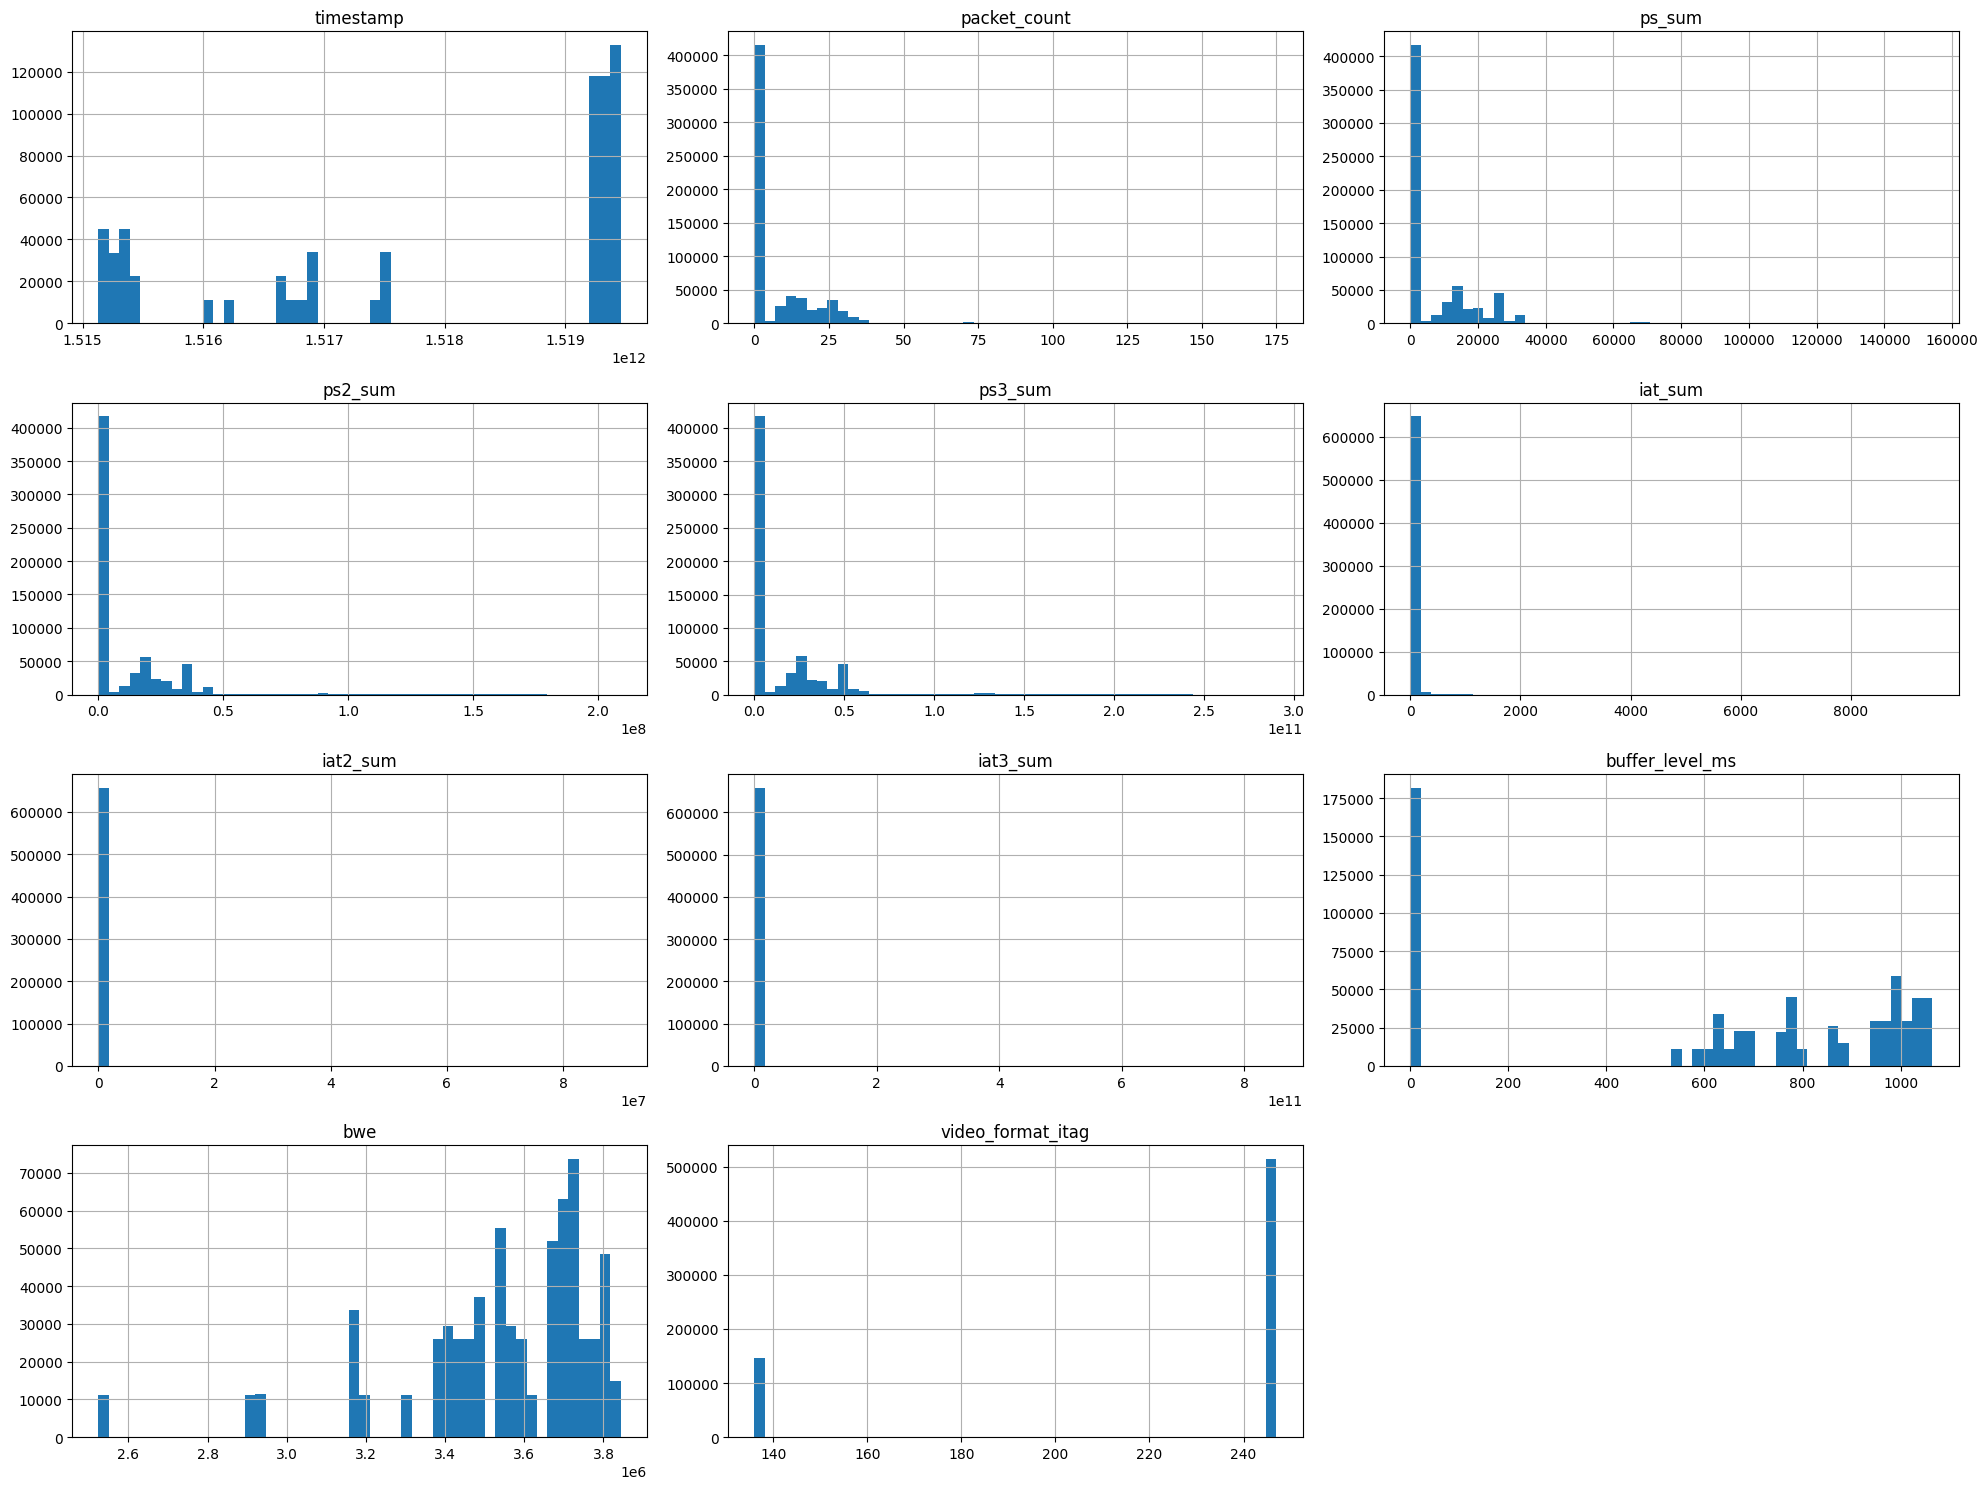

In [5]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

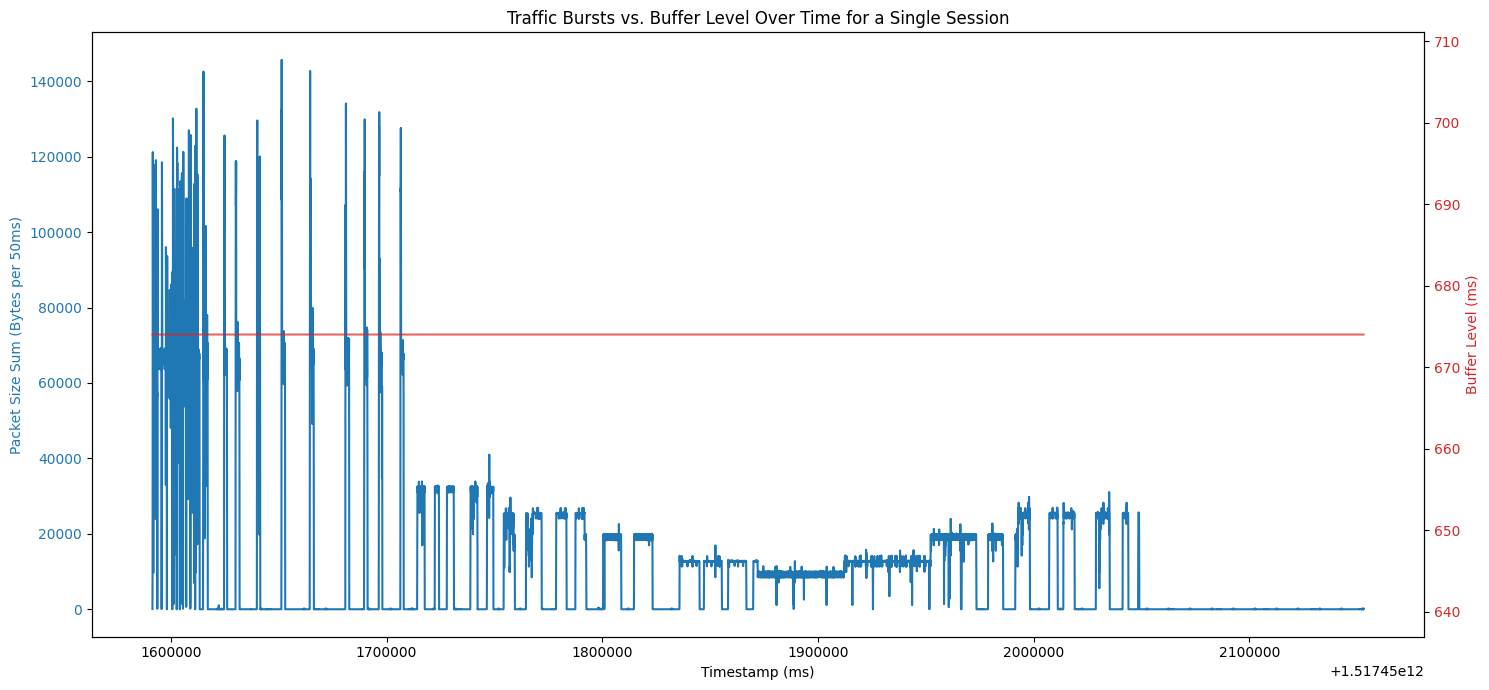

In [6]:
fig, ax1 = plt.subplots(figsize=(15, 7))

color = 'tab:blue'
ax1.set_xlabel('Timestamp (ms)')
ax1.set_ylabel('Packet Size Sum (Bytes per 50ms)', color=color)
ax1.plot(sample_df['timestamp'], sample_df['ps_sum'], color=color, label='Traffic Bursts (ps_sum)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Buffer Level (ms)', color=color)  
ax2.plot(sample_df['timestamp'], sample_df['buffer_level_ms'], color=color, alpha=0.7, label='Buffer Level')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Traffic Bursts vs. Buffer Level Over Time for a Single Session')
fig.tight_layout()
plt.show()

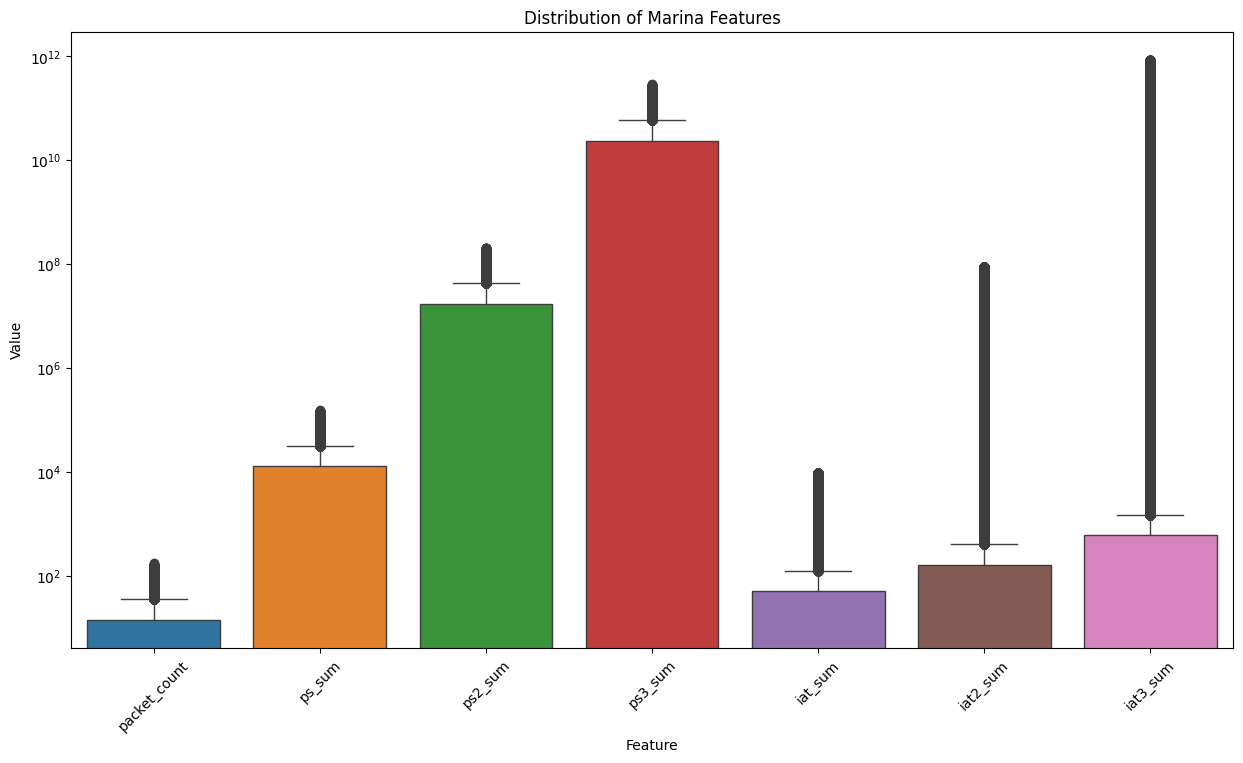

In [7]:
feature_cols = ['packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum', 'iat_sum', 'iat2_sum', 'iat3_sum']

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[feature_cols])
plt.title('Distribution of Marina Features')
plt.ylabel('Value')
plt.xlabel('Feature')

plt.xticks(rotation=45)

plt.yscale('log')
plt.show()

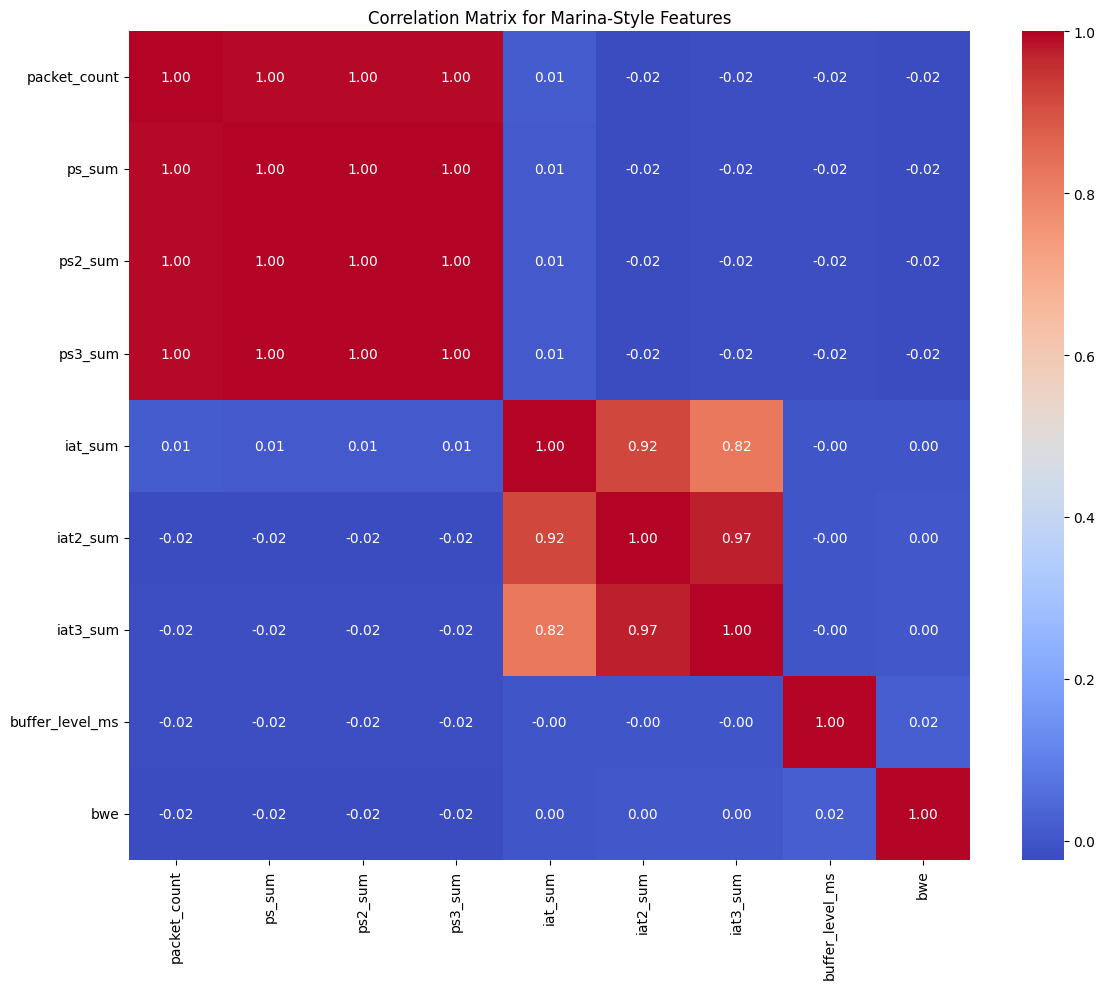

In [8]:

numerical_cols = [
    'packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum', 
    'iat_sum', 'iat2_sum', 'iat3_sum', 'buffer_level_ms', 'bwe'
]

#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Marina-Style Features')
plt.tight_layout()
plt.show()